# **Policy Gradient**

<hr>

### **Part 7**: Reinforcement Learning from Zero to One

*African Institute for Mathematical Sciences (AIMS), South Africa
10 March, 2026*

**Arnu Pretorius** - Research Scientist, InstaDeep



## **The *continuous* Numberline with a *continuous action space*.**




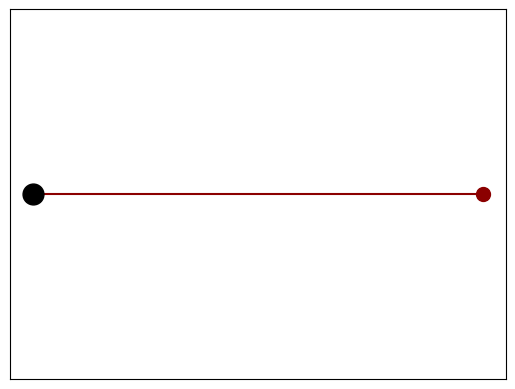

In [11]:
# @title Setup
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# hyperparameters
max_steps = 50

class NumberLineEnv:
    def __init__(self, max_steps=50, reward_type='sparse'):
        self.max_steps = max_steps
        self.reward_type = reward_type

    def reset(self, key):
        """Initialize the environment state."""
        state = (0, 0, key)
        timestep = (0, 0, False)
        return state, timestep

    def step(self, state, action):
        """Takes an action in the environment."""
        obs, step_count, key = state
        new_key, sub_key = jax.random.split(key)

        # Determine movement direction (intended or opposite)
        in_obsorbing_goal_state = obs == 1
        obs_shift = action

        # Update position based on stochastic action
        next_obs = jnp.clip(obs+obs_shift, 0, 1)

        # Calculate instantaneous reward
        is_at_goal = next_obs == 1
        reward = jax.lax.cond(
            self.reward_type == 'sparse',
            lambda x: jnp.where(x, 1, 0),
            lambda x: jnp.where(~x, -1, 0),
            is_at_goal,
        )
        done = (jnp.where(step_count == self.max_steps-1, 1, 0) + is_at_goal) > 0
        reward = jnp.where(in_obsorbing_goal_state, 0, reward)

        # Update state
        state = (next_obs, step_count + 1, new_key)
        timestep = (next_obs, reward, done)

        return state, timestep

    def _prepare_figure(self, ax):

        # Add labels and legend
        ax.set_xticks([])
        ax.set_yticks([])

    def _draw_state(self, ax, state):
        obs, _, _ = state
        obs = obs*9

        # Create a line for the state space
        states = range(10)
        ax.plot(states, [0] * len(states), color='darkred')

        # Mark agent and target state
        ax.plot(0, 0, 'o', color='darkred', markersize=10)
        ax.plot(9, 0, 'o', color='darkred', markersize=10)
        color = 'green' if obs == 9 else 'black'
        ax.plot(obs, 0, 'o', color=color, markersize=15, label='Agent')

    def render(self, state):
        # Prepare figure and axis
        fig, ax = plt.subplots()
        ax.clear()
        self._prepare_figure(ax)

        # Mark the current state of the agent
        self._draw_state(ax, state)
        plt.show()

    def animate(self, states, interval=200, save_path=None):
        fig = plt.figure()
        fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)
        ax = fig.add_subplot(111)
        plt.close(fig)
        self._prepare_figure(ax)

        def make_frame(state) -> None:
            ax.clear()
            self._prepare_figure(ax)
            self._draw_state(ax, state)

        # Create the animation object.
        self._animation = animation.FuncAnimation(
            fig,
            make_frame,
            frames=states,
            interval=interval,
        )

        # Save the animation as a gif.
        if save_path:
            self._animation.save(save_path)

        return self._animation

# create environment
env = NumberLineEnv(max_steps=max_steps)
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

# visualise environment
key = jax.random.PRNGKey(3)
env_state, timestep = reset_fn(key)
env.render(env_state)

In [12]:
def make_uniform_random_policy(burn_key):
    def policy(x, key):
        key, sub_key = jax.random.split(key)
        return jax.random.uniform(sub_key, minval=-0.2, maxval=0.2)
    return policy

policy_fn = make_uniform_random_policy
policy = policy_fn(jax.random.PRNGKey(0))

In [13]:
from matplotlib import rc
rc('animation', html='jshtml')

def animation_rollout(policy, key):
    # make animation of random policy
    env_state, (obs, _, done) = reset_fn(key)
    env_states = [env_state]
    while not done:
        key, subkey = jax.random.split(key)
        action = policy(obs, subkey)
        env_state, (obs, _, done) = step_fn(env_state, action)
        env_states.append(env_state)
    return env_states

env_states = animation_rollout(policy, key)
env.animate(env_states)

## **Actor-Critic algorithm**

### **Policy Gradient with linear action-value function approximation**

- Simple actor-critic algorithm based on action-value critic
- Using linear value function approximation: $\hat{q}_\phi(s, a) = x(s, a)^T \phi$

    * **Critic:** Updates $\phi$ by linear TD(0)

    * **Actor:** Updates $\theta$ by policy gradient


#### **Gaussian Continuous Policy**

- Define the policy $\pi_\theta$ as a Gaussian where $a \sim N(\mu_\theta(s), \sigma^2)$.
- The mean is given by $\mu(s) = x(s)^T \theta$ and variance is $\sigma^2$ fixed, such that

$$
\nabla_{\theta} \log \pi_{\theta}(a|s) = \frac{(a - \mu_\theta(s))x(s)}{\sigma^2}
$$


In [14]:
# parameters
num_episodes = 10000
gamma = 0.9
alpha = 0.05
beta = 0.05
key_init = jax.random.PRNGKey(0)

In [15]:
# Actor
def actor_x(s):
    return s

def mu(s, theta):
    return actor_x(s)*theta

def pi(key, s, theta):
    return mu(s, theta) + 0.1 * jax.random.normal(key)

def grad_log_pi(s, a, theta):
    return ((a - mu(s, theta))*actor_x(s))/ (0.1)**2

# Critic
def critic_x(s, a):
    return s*a

def q_hat(s, a, phi):
    return critic_x(s,a)*phi

def grad_q_hat(s, a, phi):
    return critic_x(s, a)

def grad_loss(s, a, phi, q_target):
    return (q_target-q_hat(s, a, phi))*grad_q_hat(s, a, phi)

## **QAC Algorithm**

\begin{align*}
& \textbf{Input: } \text{differentiable functions } \hat{q}_\phi, \pi_\theta \\
& \textbf{Algorithm parameter: } \text{step sizes } \alpha, \beta \in (0,1] \\
& \textbf{Initialize: } \text{weights } \phi, \theta \text{ arbitrarily} \\
& \textbf{For} \text{ each episode } \textbf{do} \\
& \hspace{1cm} \text{Initialize } S \\
& \hspace{1cm} \text{Choose } A \text{ from } S \text{ using policy } \pi_\theta \\
& \hspace{1cm} \textbf{While } S \text{ is not terminal } \textbf{do} \\
& \hspace{1cm} \hspace{1cm} \text{Take action } A \text{ , observe } R, S'\\
& \hspace{1cm} \hspace{1cm} \text{Choose } A' \text{ from } S' \text{ using policy } \pi_\theta \\
& \hspace{1cm} \hspace{1cm} \theta \leftarrow \theta + \alpha \nabla_\theta \log \pi_\theta(A|S) \hat{q}_\phi(S, A)\\
& \hspace{1cm} \hspace{1cm} δ = R + \gamma \hat{q}_\phi(S', A') -  \hat{q}_\phi(S, A)\\
& \hspace{1cm} \hspace{1cm} \phi \leftarrow \phi + \beta \delta x(S, A) \\
& \hspace{1cm} \hspace{1cm} A \leftarrow A', S \leftarrow S' \\
& \hspace{1cm} \textbf{End while} \\
& \textbf{End for}
\end{align*}



In [16]:
def scan_step_fn(state, unused_t):
    theta, phi, env_state = state
    obs, _, key = env_state
    key, action_key, next_action_key = jax.random.split(key, 3)

    # take action in the environment
    action = pi(action_key, obs, phi)
    env_state, timestep = step_fn(env_state, action)
    next_obs, reward, done = timestep

    # get next action
    next_action = pi(next_action_key, next_obs, theta)

    # actor update
    theta += alpha*grad_log_pi(obs, action, theta)*q_hat(obs, action, phi)

    # critic update
    target = gamma * q_hat(next_obs, next_action, phi) * (1-done) + reward
    phi += beta*grad_loss(obs, action, phi, target)
    return (theta, phi, env_state), (theta, phi)

def scan_episode_fn(state, unused_t):
    key, theta, phi, count = state
    key, reset_key = jax.random.split(key)
    initial_env_state, _ = reset_fn(reset_key)

    initial_state = (theta, phi, initial_env_state)
    (theta, phi, _), (theta_hist, phi_hist) = jax.lax.scan(scan_step_fn, initial_state, jnp.arange(max_steps))
    return (key, theta, phi, count+1), (theta_hist, phi_hist)

def q_actor_critic(key, theta, phi):
    initial_state = (key, theta, phi, 1)
    (_, theta, phi, _), (theta_hist, phi_hist) = jax.lax.scan(scan_episode_fn, initial_state, jnp.arange(num_episodes))
    return theta, phi, theta_hist, phi_hist

q_actor_critic_fn = jax.jit(q_actor_critic)

In [17]:
key, theta_key, phi_key = jax.random.split(key_init, 3)
theta_init = -jax.random.normal(theta_key)
phi_init = -jax.random.normal(phi_key)
theta_init, phi_init

(Array(2.4424558, dtype=float32), Array(-1.2956359, dtype=float32))

In [18]:
theta_updated, phi_updated, theta_hist, phi_hist = q_actor_critic_fn(key_init, theta_init, phi_init)
theta_updated, phi_updated

(Array(0.28458393, dtype=float32), Array(0.21127851, dtype=float32))

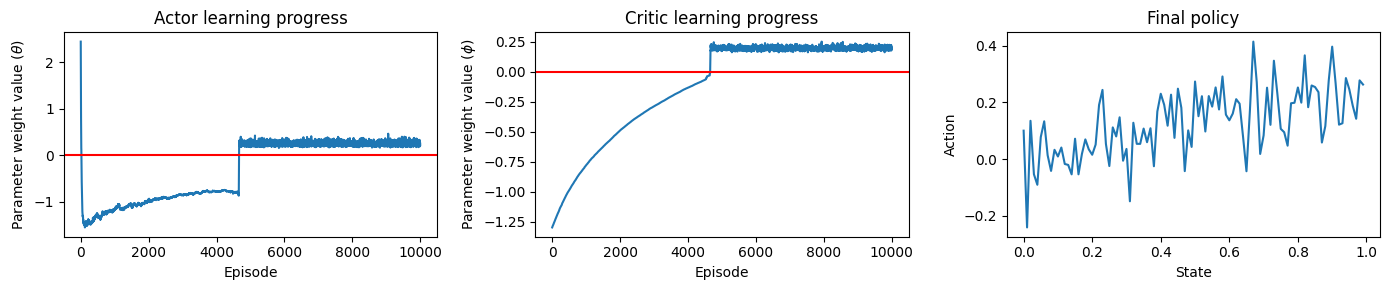

In [19]:
plt.figure(figsize=(14, 3))

plt.subplot(1, 3, 1)
plt.xlabel('Episode')
plt.ylabel(r'Parameter weight value ($\theta$)')
plt.title('Actor learning progress')
plt.plot(theta_hist.ravel()[::max_steps])
plt.axhline(y=0, color='r', linestyle='-')

plt.subplot(1, 3, 2)
plt.xlabel('Episode')
plt.ylabel(r'Parameter weight value ($\phi$)')
plt.title('Critic learning progress')
plt.plot(phi_hist.ravel()[::max_steps])
plt.axhline(y=0, color='r', linestyle='-')

states = jnp.arange(0, 1, 0.01)
keys = jax.random.split(key_init, len(states))
actions = [pi(key, s, theta_updated) for key, s in zip(keys, states)]
plt.subplot(1, 3, 3)
plt.xlabel('State')
plt.ylabel('Action')
plt.title('Final policy')
plt.plot(states, actions)

plt.tight_layout()
plt.show()

In [20]:
def linear_policy(obs, key):
    return pi(key, obs, theta_updated)

env_states = animation_rollout(linear_policy, key)
env.animate(env_states)